Loading MP3 audio file: song.mp3...


C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing IR: 1_Echo_Delay...
  -> Processed track saved to: output_1_Echo_Delay.wav
Processing IR: 2_Room_Reverberation...
  -> Processed track saved to: output_2_Room_Reverberation.wav
Processing IR: 3_LowPass_Dampening...
  -> Processed track saved to: output_3_LowPass_Dampening.wav


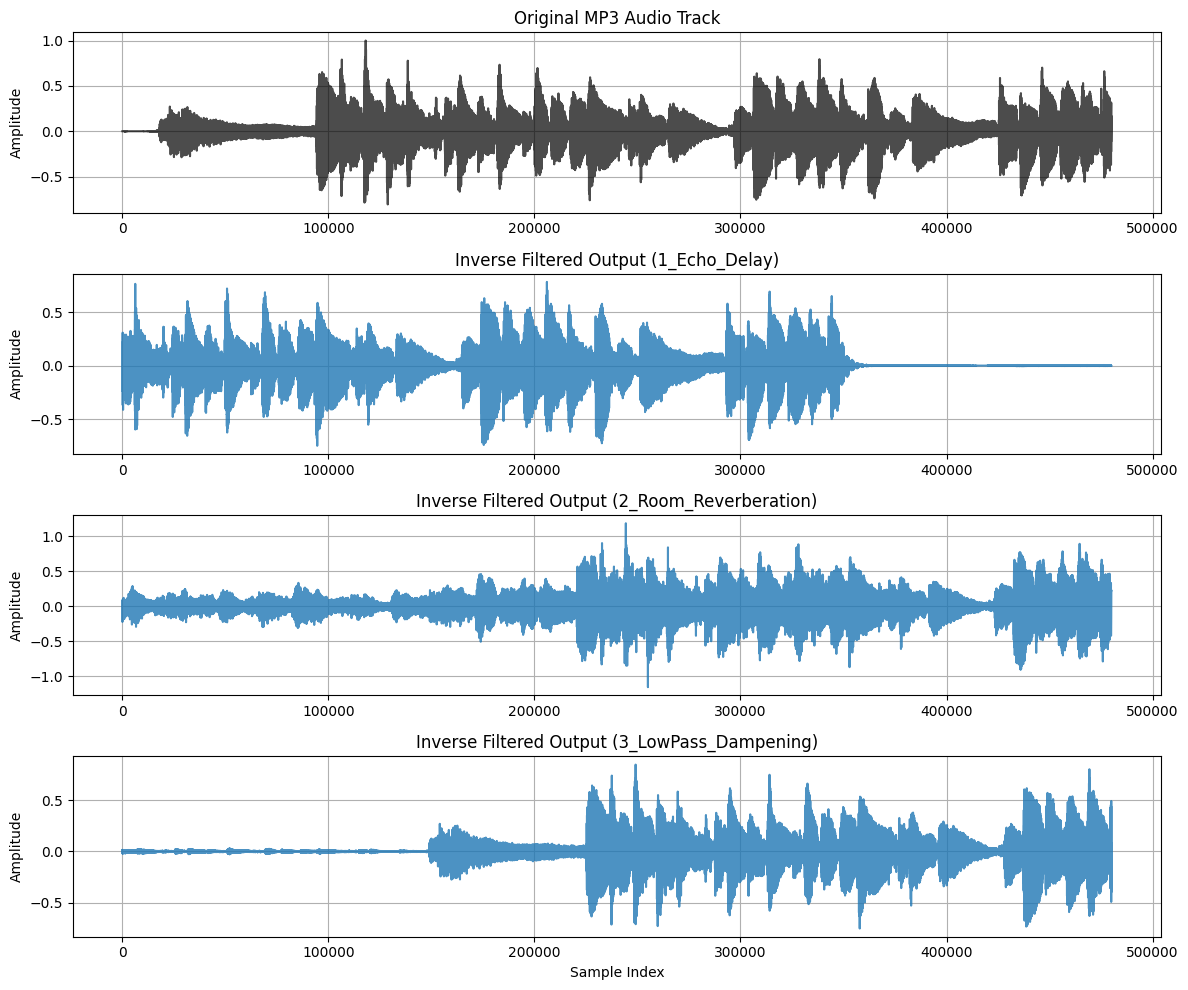

In [ ]:
# AIM: Audio Convolution and Inverse Filtering for Background Music Suppression
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.io.wavfile as wavfile
import librosa

def create_impulse_responses(sr):
    delay_samples = int(0.05 * sr)  
    ir_echo = np.zeros(delay_samples + 1)
    ir_echo[0] = 1.0       
    ir_echo[-1] = 0.5      

    t_ir = np.linspace(0, 0.2, int(0.2 * sr))
    ir_reverb = np.exp(-15 * t_ir) * np.random.randn(len(t_ir))
    ir_reverb[0] = 1.0    
    
    ir_lowpass = signal.firwin(101, cutoff=2500, fs=sr)

    return {
        "1_Echo_Delay": ir_echo,
        "2_Room_Reverberation": ir_reverb,
        "3_LowPass_Dampening": ir_lowpass
    }

def regularized_inverse_filter(h, epsilon=1e-2, n_fft=262144):
    H = np.fft.rfft(h, n=n_fft)
    G = np.conj(H) / (np.abs(H)**2 + epsilon)
    g = np.fft.irfft(G, n=n_fft)
    return np.real(g)

def run_audio_experiment(audio_path):
    print(f"Loading MP3 audio file: {audio_path}...")
    
    audio_data, sr = librosa.load(audio_path, sr=None, mono=True, duration=10.0)
    
    audio_data = audio_data / np.max(np.abs(audio_data))

    impulse_responses = create_impulse_responses(sr)

    plt.figure(figsize=(12, 10))
    
    plt.subplot(4, 1, 1)
    plt.plot(audio_data, color='k', alpha=0.7)
    plt.title("Original MP3 Audio Track")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plot_idx = 2

    for name, ir in impulse_responses.items():
        print(f"Processing IR: {name}...")

        convolved_audio = signal.fftconvolve(audio_data, ir, mode='same')

        inv_filter = regularized_inverse_filter(ir, epsilon=1e-2)

        filtered_audio = signal.fftconvolve(convolved_audio, inv_filter, mode='same')
        filtered_audio = filtered_audio[:len(audio_data)]

        output_filename = f"output_{name}.wav"
        wavfile.write(output_filename, sr, (filtered_audio * 32767).astype(np.int16))
        print(f"  -> Processed track saved to: {output_filename}")

        plt.subplot(4, 1, plot_idx)
        plt.plot(filtered_audio, alpha=0.8)
        plt.title(f"Inverse Filtered Output ({name})")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plot_idx += 1

    plt.xlabel("Sample Index")
    plt.tight_layout()
    plt.show()

run_audio_experiment('song.mp3')